# CSC4093: Neural Networks and Deep Learning
## Programming Assignment 01 — Tweet Classification using LSTM Networks

**Student Name:** Mohammadhu Umair  
**Student ID:** S/20/534  

## 1. Introduction

This notebook implements two LSTM based deep learning models to classify tweets from the PHM dataset as either personal health mentions (label 1) or non-personal health mentions (label 0). Two architectures are compared: a Stacked LSTM and a Bidirectional LSTM. The models are evaluated on accuracy, precision, recall and F1 score.

Tweets are informal and noisy, which makes classification harder than standard text. Careful preprocessing and regularization techniques were applied to handle this.

## 2. Imports

All required libraries are loaded below. TensorFlow/Keras is used for model building, NLTK for stop word removal, and scikit-learn for evaluation metrics.

In [67]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, json
import pandas as pd
import numpy as np
import re
import nltk
import seaborn as sns
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, precision_score,
                              recall_score, f1_score)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Bidirectional,
                                     Dense, Dropout, SpatialDropout1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

nltk.download('stopwords', quiet=True)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 10

## 3. Data Preparation

The PHM dataset is loaded from CSV files. It contains tweets labelled as personal health mentions (1) or non-personal health mentions (0). An 80/20 split is applied on the training data to create a validation set used during model training to monitor generalisation.

In [68]:
train_df = pd.read_csv('phm_train.csv')
test_df  = pd.read_csv('phm_test.csv')

print(f'Train samples : {len(train_df)}')
print(f'Test  samples : {len(test_df)}')
print(f'\nLabel distribution (train):')
print(train_df['label'].value_counts())

Train samples : 9991
Test  samples : 3331

Label distribution (train):
label
0    7091
1    2900
Name: count, dtype: int64


## 4. Preprocessing

Tweets are cleaned through the following steps:

- Lowercasing all text
- Removing URLs, @mentions and hashtag symbols
- Removing non-alphabetic characters
- Removing stop words — with an important exception: negation words like *not*, *no*, and *never* are kept. Dropping them would completely reverse the meaning of many health-related phrases. For example, *not feeling well* would become *feeling well*.
- Removing single-character tokens

In [69]:
NEGATIONS = {'not', 'no', 'never', 'nor', 'neither', 'without',
             'cannot', 'cant', 'wont', 'dont', 'doesnt', 'didnt',
             'wasn', 'weren', 'isn', 'aren', 'hasn', 'haven', 'hadn'}
english_stops = set(stopwords.words('english')) - NEGATIONS

def clean(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [w for w in text.split() if w not in english_stops and len(w) > 1]
    return ' '.join(tokens)

train_df['clean'] = train_df['tweet'].apply(clean)
test_df['clean']  = test_df['tweet'].apply(clean)

x_train, x_val, y_train, y_val = train_test_split(
    train_df['clean'], train_df['label'],
    test_size=0.2, random_state=42
)
print(f'Train size : {len(x_train)} | Val size : {len(x_val)}')

Train size : 7992 | Val size : 1999


## 5. Tokenization and Sequence Padding

A Keras Tokenizer is fitted on training data only to avoid leaking test vocabulary into the model. Each word is mapped to an integer index by frequency. Sequences are padded to the 90th percentile of training lengths rather than the maximum, which keeps the input size reasonable without truncating most tweets.

In [70]:
token = Tokenizer(lower=True)
token.fit_on_texts(x_train)

lengths     = [len(t.split()) for t in x_train]
max_len     = int(np.percentile(lengths, 90))
total_words = len(token.word_index) + 1

print(f'Max sequence length (90th pct) : {max_len}')
print(f'Vocabulary size                : {total_words}')

def seq_and_pad(data):
    return pad_sequences(
        token.texts_to_sequences(data),
        maxlen=max_len, padding='post', truncating='post'
    )

x_train_pad = seq_and_pad(x_train)
x_val_pad   = seq_and_pad(x_val)
x_test_pad  = seq_and_pad(test_df['clean'])

Max sequence length (90th pct) : 15
Vocabulary size                : 11136


## 6. Hyperparameters

These settings were chosen after observing overfitting in early runs where training accuracy climbed above 93% while validation accuracy stagnated near 80%. Increasing dropout and reducing LSTM units helped close that gap.

In [71]:
EMBED_DIM  = 32
LSTM_OUT   = 64
DROPOUT    = 0.5
REC_DROP   = 0.3
EPOCHS     = 20
BATCH_SIZE = 128
REG        = l2(1e-4)

print(f'Embedding dim      : {EMBED_DIM}')
print(f'LSTM units (L1/L2) : {LSTM_OUT} / {LSTM_OUT//2}')
print(f'Dropout            : {DROPOUT}')
print(f'Recurrent dropout  : {REC_DROP}')
print(f'Batch size         : {BATCH_SIZE}')
print(f'Max epochs         : {EPOCHS}')
print(f'L2 regularization  : 1e-4')

def make_embedding_layer():
    return Embedding(total_words, EMBED_DIM, input_length=max_len)

Embedding dim      : 32
LSTM units (L1/L2) : 64 / 32
Dropout            : 0.5
Recurrent dropout  : 0.3
Batch size         : 128
Max epochs         : 20
L2 regularization  : 1e-4


## 7. Model Definitions

### 7.1 Stacked LSTM

Two LSTM layers are stacked in sequence. The first layer returns its full sequence of hidden states so the second layer has a temporal view of the whole tweet. SpatialDropout1D drops entire embedding feature dimensions which is more effective than element-wise dropout for sequence data. L2 regularization is added to both LSTM kernels and the Dense layer.

In [72]:
def build_stacked_lstm():
    model = Sequential([
        make_embedding_layer(),
        SpatialDropout1D(0.4),
        LSTM(LSTM_OUT, return_sequences=True,
             dropout=DROPOUT, recurrent_dropout=REC_DROP,
             kernel_regularizer=REG, recurrent_regularizer=REG),
        LSTM(LSTM_OUT // 2,
             dropout=DROPOUT, recurrent_dropout=REC_DROP,
             kernel_regularizer=REG, recurrent_regularizer=REG),
        Dense(32, activation='relu', kernel_regularizer=REG),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

stacked_model = build_stacked_lstm()
stacked_model.summary()

C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_11            │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 7.2 Bidirectional LSTM

Each LSTM layer is wrapped in a Bidirectional layer so the sequence is processed both forward and backward. The outputs of both directions are concatenated at each time step, doubling the contextual information available to the model. This is particularly useful for health mention tweets where meaning often depends on words that appear later in the sentence.

In [73]:
def build_bi_lstm():
    model = Sequential([
        make_embedding_layer(),
        SpatialDropout1D(0.4),
        Bidirectional(LSTM(LSTM_OUT, return_sequences=True,
                           dropout=DROPOUT, recurrent_dropout=REC_DROP,
                           kernel_regularizer=REG, recurrent_regularizer=REG)),
        Bidirectional(LSTM(LSTM_OUT // 2,
                           dropout=DROPOUT, recurrent_dropout=REC_DROP,
                           kernel_regularizer=REG, recurrent_regularizer=REG)),
        Dense(32, activation='relu', kernel_regularizer=REG),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

bi_model = build_bi_lstm()
bi_model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_12            │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 8. Callbacks

**EarlyStopping** stops training when validation loss does not improve for 5 consecutive epochs and restores the weights from the best epoch.

**ReduceLROnPlateau** halves the learning rate when validation loss stalls for 2 epochs, allowing the optimiser to converge more carefully in later training stages.

In [74]:
def get_callbacks():
    es  = EarlyStopping(monitor='val_loss', patience=5,
                        restore_best_weights=True, verbose=1)
    rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                            patience=2, min_lr=1e-6, verbose=1)
    return [es, rlr]

## 9. Training

### 9.1 Stacked LSTM

In [75]:
h_stacked = stacked_model.fit(
    x_train_pad, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(x_val_pad, y_val),
    callbacks=get_callbacks(), verbose=1
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.7035 - loss: 0.6445 - val_accuracy: 0.6983 - val_loss: 0.6092 - learning_rate: 0.0010
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.7706 - loss: 0.5216 - val_accuracy: 0.7919 - val_loss: 0.4776 - learning_rate: 0.0010
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.8308 - loss: 0.4148 - val_accuracy: 0.8039 - val_loss: 0.4482 - learning_rate: 0.0010
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8595 - loss: 0.3637 - val_accuracy: 0.8089 - val_loss: 0.4574 - learning_rate: 0.0010
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8770 - loss: 0.3333
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8796 - loss: 0.3273 - val_accuracy: 0.8049 - val_loss: 0.4674 - learning_rate: 0.0010
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8958 - loss: 0.2874 - val_accu

### 9.2 Bidirectional LSTM

In [76]:
h_bi = bi_model.fit(
    x_train_pad, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(x_val_pad, y_val),
    callbacks=get_callbacks(), verbose=1
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 91ms/step - accuracy: 0.7095 - loss: 0.6561 - val_accuracy: 0.6983 - val_loss: 0.5993 - learning_rate: 0.0010
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.7773 - loss: 0.5160 - val_accuracy: 0.8039 - val_loss: 0.4798 - learning_rate: 0.0010
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.8392 - loss: 0.4095 - val_accuracy: 0.8134 - val_loss: 0.4477 - learning_rate: 0.0010
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 0.8749 - loss: 0.3330 - val_accuracy: 0.8139 - val_loss: 0.4781 - learning_rate: 0.0010
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8922 - loss: 0.2883
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.8868 - loss: 0.3006 - val_accuracy: 0.8019 - val_loss: 0.4947 - learning_rate: 0.0010
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.9097 - loss: 0.2581 - val_acc

## 10. Training History

The plots below show accuracy and loss over epochs for both models side by side. When regularization is working well, training and validation curves should move together rather than diverging.

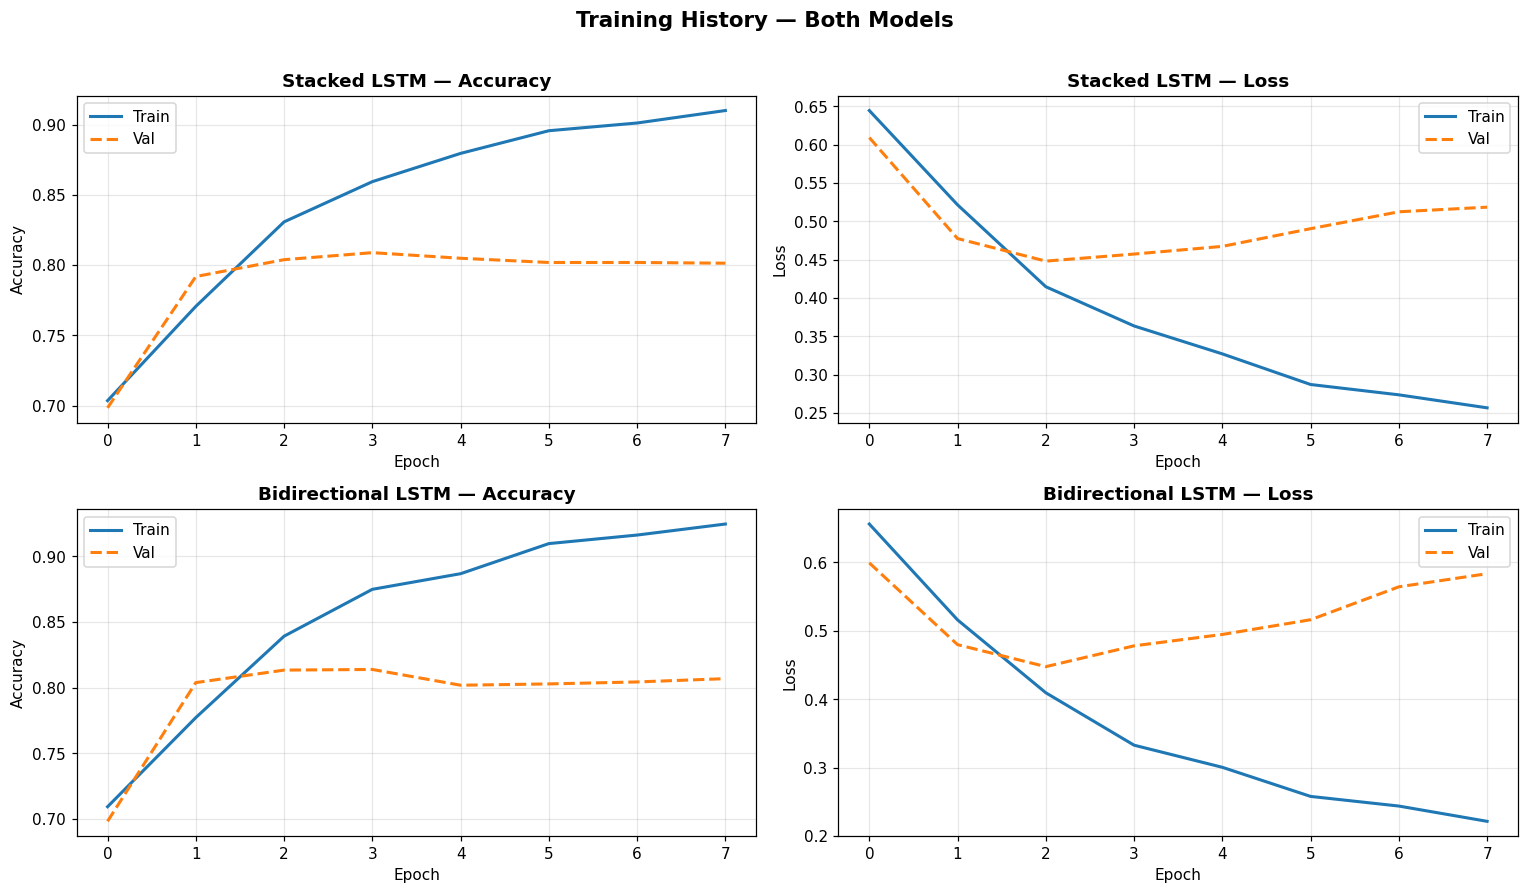

In [77]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Training History — Both Models', fontsize=14, fontweight='bold', y=1.01)

# ── Row 0: Stacked LSTM ──────────────────────────────────────────────
axes[0][0].set_title('Stacked LSTM — Accuracy', fontweight='bold')
axes[0][0].plot(h_stacked.history['accuracy'],     label='Train', linewidth=2)
axes[0][0].plot(h_stacked.history['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
axes[0][0].set_xlabel('Epoch')
axes[0][0].set_ylabel('Accuracy')
axes[0][0].legend()
axes[0][0].grid(True, alpha=0.3)

axes[0][1].set_title('Stacked LSTM — Loss', fontweight='bold')
axes[0][1].plot(h_stacked.history['loss'],     label='Train', linewidth=2)
axes[0][1].plot(h_stacked.history['val_loss'], label='Val',   linewidth=2, linestyle='--')
axes[0][1].set_xlabel('Epoch')
axes[0][1].set_ylabel('Loss')
axes[0][1].legend()
axes[0][1].grid(True, alpha=0.3)

# ── Row 1: Bidirectional LSTM ─────────────────────────────────────────
axes[1][0].set_title('Bidirectional LSTM — Accuracy', fontweight='bold')
axes[1][0].plot(h_bi.history['accuracy'],     label='Train', linewidth=2)
axes[1][0].plot(h_bi.history['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
axes[1][0].set_xlabel('Epoch')
axes[1][0].set_ylabel('Accuracy')
axes[1][0].legend()
axes[1][0].grid(True, alpha=0.3)

axes[1][1].set_title('Bidirectional LSTM — Loss', fontweight='bold')
axes[1][1].plot(h_bi.history['loss'],     label='Train', linewidth=2)
axes[1][1].plot(h_bi.history['val_loss'], label='Val',   linewidth=2, linestyle='--')
axes[1][1].set_xlabel('Epoch')
axes[1][1].set_ylabel('Loss')
axes[1][1].legend()
axes[1][1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Evaluation

Both models are evaluated on the held-out test set. The confusion matrices are displayed side by side for easy comparison. Precision, recall and F1 score are also printed to give a fuller picture of performance beyond accuracy alone.

In [78]:
y_pred_stacked = (stacked_model.predict(x_test_pad, verbose=0) >= 0.5).astype(int).flatten()
y_pred_bi      = (bi_model.predict(x_test_pad, verbose=0) >= 0.5).astype(int).flatten()
y_true         = test_df['label'].values

for name, y_pred in [('Stacked LSTM (2 Layers)', y_pred_stacked),
                     ('Bidirectional LSTM (2 Layers)', y_pred_bi)]:
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f'=== {name} ===')
    print(f'Accuracy  : {acc*100:.2f}%')
    print(f'Precision : {prec:.4f}')
    print(f'Recall    : {rec:.4f}')
    print(f'F1 Score  : {f1:.4f}')
    print()
    print(classification_report(y_true, y_pred))
    print('-' * 50)

=== Stacked LSTM (2 Layers) ===
Accuracy  : 82.47%
Precision : 0.8189
Recall    : 0.8247
F1 Score  : 0.8187

              precision    recall  f1-score   support

           0       0.85      0.92      0.88      2364
           1       0.74      0.60      0.67       967

    accuracy                           0.82      3331
   macro avg       0.80      0.76      0.77      3331
weighted avg       0.82      0.82      0.82      3331

--------------------------------------------------
=== Bidirectional LSTM (2 Layers) ===
Accuracy  : 82.56%
Precision : 0.8207
Recall    : 0.8256
F1 Score  : 0.8218

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      2364
           1       0.73      0.63      0.68       967

    accuracy                           0.83      3331
   macro avg       0.79      0.77      0.78      3331
weighted avg       0.82      0.83      0.82      3331

--------------------------------------------------


## 12. Confusion Matrices

The confusion matrices below show the breakdown of correct and incorrect predictions for each model on the test set.

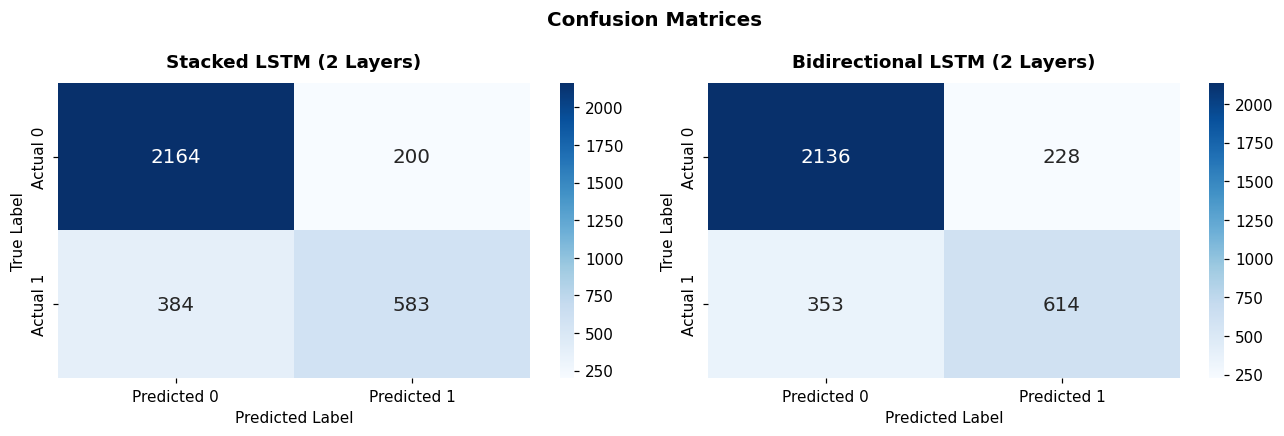

In [79]:
cm_stacked = confusion_matrix(y_true, y_pred_stacked)
cm_bi      = confusion_matrix(y_true, y_pred_bi)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')

sns.heatmap(cm_stacked, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'],
            annot_kws={'size': 13})
ax1.set_title('Stacked LSTM (2 Layers)', fontweight='bold', pad=10)
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

sns.heatmap(cm_bi, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'],
            annot_kws={'size': 13})
ax2.set_title('Bidirectional LSTM (2 Layers)', fontweight='bold', pad=10)
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## 13. Performance Comparison

The bar chart below gives a visual comparison of all four metrics across both models.

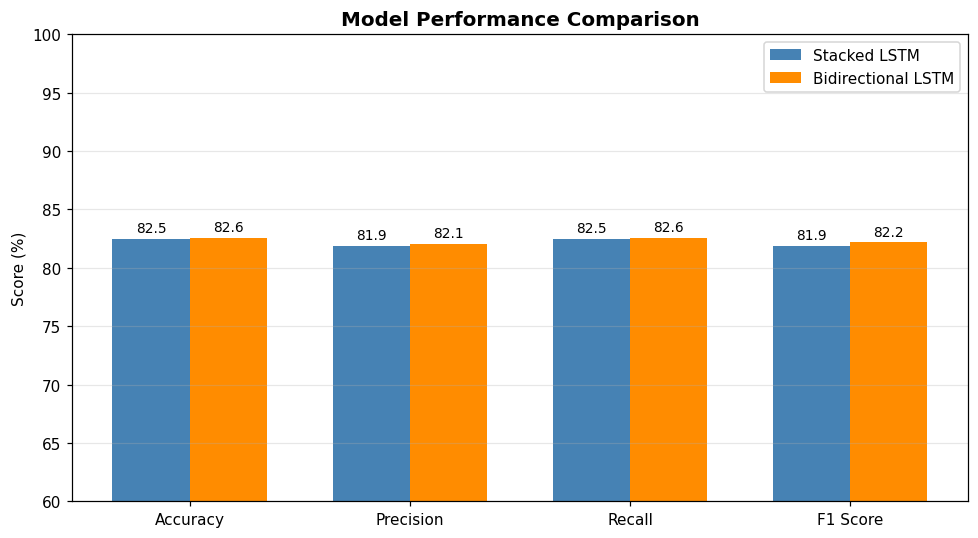

In [80]:
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

stacked_vals = [
    accuracy_score(y_true, y_pred_stacked) * 100,
    precision_score(y_true, y_pred_stacked, average='weighted', zero_division=0) * 100,
    recall_score(y_true, y_pred_stacked, average='weighted', zero_division=0) * 100,
    f1_score(y_true, y_pred_stacked, average='weighted', zero_division=0) * 100
]
bi_vals = [
    accuracy_score(y_true, y_pred_bi) * 100,
    precision_score(y_true, y_pred_bi, average='weighted', zero_division=0) * 100,
    recall_score(y_true, y_pred_bi, average='weighted', zero_division=0) * 100,
    f1_score(y_true, y_pred_bi, average='weighted', zero_division=0) * 100
]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, stacked_vals, width, label='Stacked LSTM',       color='steelblue')
bars2 = ax.bar(x + width/2, bi_vals,      width, label='Bidirectional LSTM', color='darkorange')

ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('Score (%)')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(60, 100)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()